In [1]:
import numpy as np
from typing import Dict, Any
from tqdm import tqdm

from model_ranking.correlation import calculate_correlation_statistics
from model_ranking.feature_ranking import get_precomputed_feature_path
from model_ranking.logme import log_maximum_evidence
from model_ranking.plots import plot_performance_vs_transfer_metric
from model_ranking.results import (
    get_NA_performance_score,
    transfer_results_to_arrays,
)
from model_ranking.utils import load_npz

INFO: P [MainThread] 2025-08-08 17:03:33,718 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


In [2]:
Unet_models = ["E_model5", "Hm_model4", "Rm_model4", "V_model2"]
Unet_models_NA = ["E_model_NA2", "Hm_model_NA2", "Rm_model_NA2", "V_model_NA2"]
Unetr_models = ["E_model_Unetr2", "Hm_model_Unetr2", "Rm_model_Unetr2"]
ResUnet_models = ["E_model_Res1", "Hm_model_Res1", "Rm_model_Res1", "V_model_Res1"]

In [3]:
targets = ["EPFL", "Hmito", "Rmito", "VNC"]

source_models = Unet_models + Unet_models_NA + Unetr_models + ResUnet_models
feature_base_path = "/scratch/talks/sampled_features/semantic_segmentation/mitochondria"
performance_base_path = "/scratch/talks/consistency_results/patch_segmentation/mitochondria"
save_keys = {
    "NA": "decoders.2",
    "Unetr": "decoder2",
    "Res": "decoders.3",
}

Processing target: EPFL


100%|██████████| 15/15 [00:16<00:00,  1.08s/it]


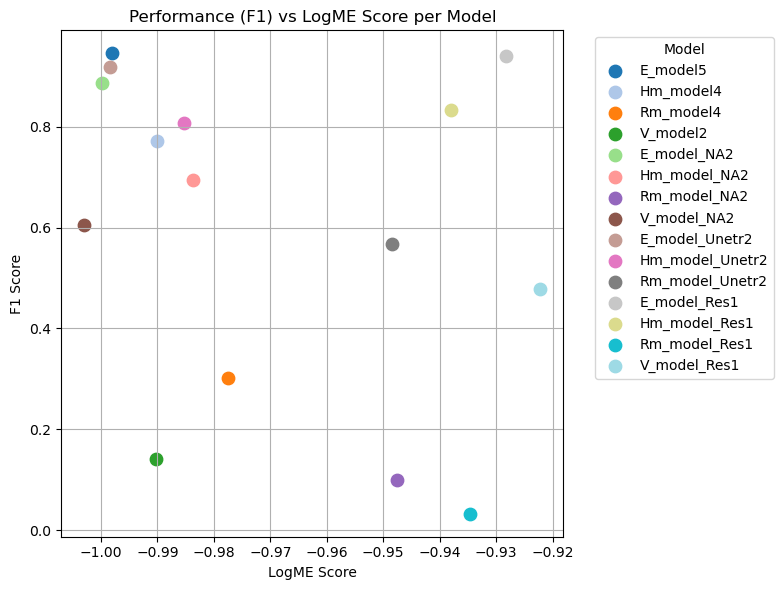

Processing target: Hmito


100%|██████████| 15/15 [00:39<00:00,  2.63s/it]


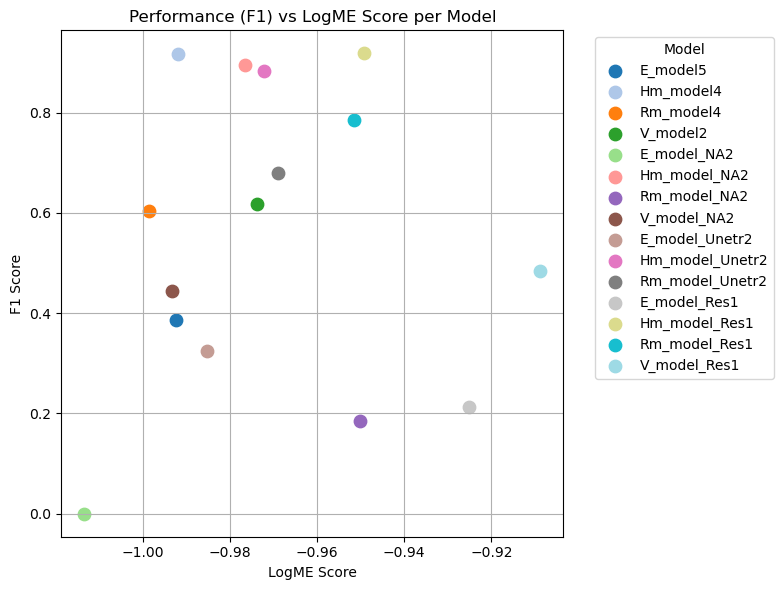

Processing target: Rmito


100%|██████████| 15/15 [00:41<00:00,  2.75s/it]


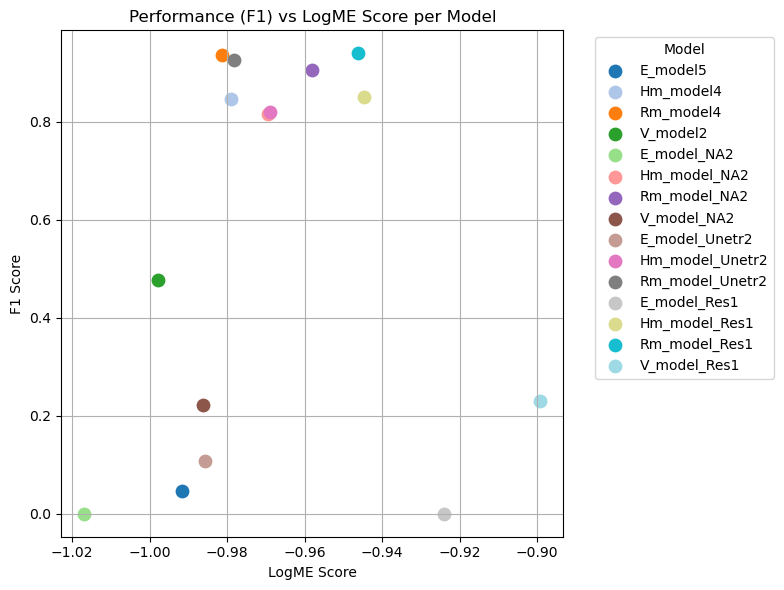

Processing target: VNC


100%|██████████| 15/15 [00:06<00:00,  2.40it/s]


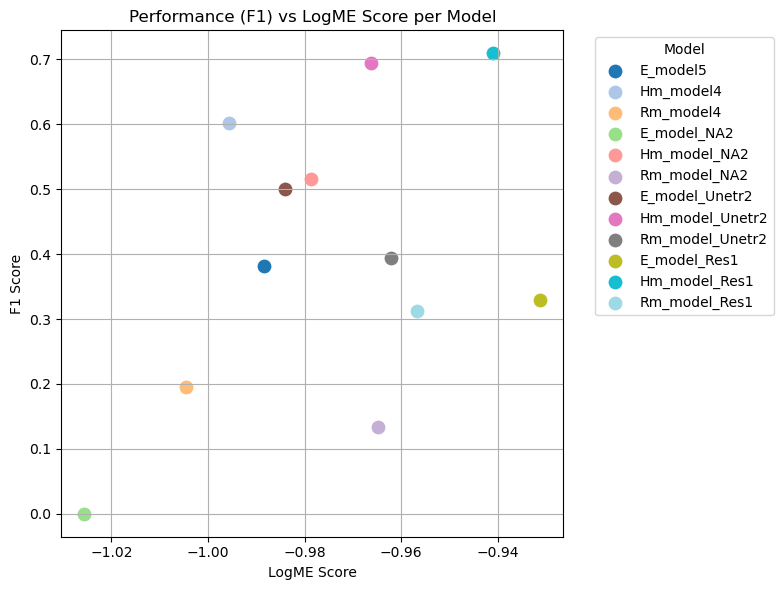

In [4]:
logme_per_target: Dict[str, Dict[str, float]] = {}
performance_per_target: Dict[str, Dict[str, float]] = {}
feature_ids = list(save_keys.keys())
for target in targets:
    print(f"Processing target: {target}")
    performance_per_model: Dict[str, Any] = {}
    logme_per_model: Dict[str, float] = {}
    for model in tqdm(source_models):
        if ("V" in model) and (target == "VNC"):
            continue
        else:
            model_identifier = model.split('_')[-1][:-1]
            if model_identifier in feature_ids:
                key = save_keys[model_identifier]
            else:
                key = "decoders.2"

            feature_path = get_precomputed_feature_path(model, target, feature_base_path)
            features = load_npz(feature_path, f"{key}_features")
            labels = load_npz(feature_path, f"{key}_labels")

            performance_score = get_NA_performance_score(model, target, performance_base_path)
            performance_per_model[model] = np.median(performance_score[:, 1])

            non_zero_patch_ids = np.where(~np.all(labels == 0, axis=1))[0]
            features = features[non_zero_patch_ids]
            labels = labels[non_zero_patch_ids]

            features_flat = features.reshape(-1, features.shape[-1])
            labels_flat = labels.reshape(-1)

            logme = log_maximum_evidence(features_flat, labels_flat)
            logme_per_model[model] = logme

    logme_per_target[target] = logme_per_model
    performance_per_target[target] = performance_per_model
    plot_performance_vs_transfer_metric(performance_per_model, logme_per_model, metric_name="LogME")

In [5]:
per_target_KT = np.zeros((len(targets), 1, 2))
per_target_SP = np.zeros((len(targets), 1, 2))
per_target_PE = np.zeros((len(targets), 1, 2))
for i, target in enumerate(targets):
    logme_scores, NA_perf_scores = transfer_results_to_arrays(
        logme_per_target[target],
        performance_per_target[target],
    )

    (per_target_KT[i], 
        per_target_SP[i], 
        per_target_PE[i]
    ) = calculate_correlation_statistics(
            logme_scores,
            NA_perf_scores,
        )

In [6]:
import pandas as pd
idx = 0
df = pd.DataFrame(
    {
        "kt": per_target_KT[:, idx, 0], 
        "kt pval": per_target_KT[:, idx, 1], 
        "s rho": per_target_SP[:, idx, 0], 
        "s rho pval": per_target_SP[:, idx, 1], 
        "pr": per_target_PE[:, idx, 0], 
        "pr pval": per_target_PE[:, idx, 1]
    },
)
df["targets"] = targets
df = df.set_index("targets")
df.index = pd.MultiIndex.from_product([["Mito"], df.index], names=["Task", "targets"])
# Round all float columns to 2 significant figures
df = df.map(lambda x: round(x, 2) if isinstance(x, float) else x)
print(df)

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL    -0.30     0.27  -0.33        0.20 -0.24     0.24
     Hmito    0.05     0.85   0.17        0.59  0.10     0.67
     Rmito    0.09     0.75   0.32        0.26  0.25     0.23
     VNC      0.41     0.18   0.25        0.44  0.21     0.39
